# Hybrid Quantum–Classical Graph Neural Network Benchmark

## Overview

This notebook presents the analysis of experiments conducted in the **qgnn-lite** project, which investigates a hybrid architecture combining classical graph neural networks with a variational quantum circuit (VQC).

The core idea of the project is to evaluate whether a **quantum head** can serve as an alternative to a classical neural network head in graph classification tasks.

The model architecture follows a simple hybrid p
iGraph → GCN Backbone → Global Pooling → Prediction Head
├── MLP (classical baseline)
└── VQC (variational quantum circuit)


The **GCN backbone** extracts graph-level embeddings, which are then passed to one of two heads:

- **MLP head** – a classical multilayer perceptron used as the baseline model
- **VQC head** – a variational quantum circuit implemented with PennyLane (`lightning.qubit`) and simulated on a classical CPU

This setup allows us to compare classical and quantum components under identical conditions for graph feature extraction.

---

## Goals of the Experiment

The main objective of this benchmark is to explore the trade-offs between classical and quantum model components.

Specifically, we aim to analyze:

- **Predictive performance** (accuracy) of classical vs quantum heads
- **Computational cost** of classical and quantum inference
- **Scalability** of the VQC with respect to the number of qubits
- The practicality of hybrid quantum–classical architectures under classical simulation constraints

---

## Datasets

Experiments are performed on two standard graph classification datasets from the **TUDataset** collection:

- **MUTAG** – a small molecular graph dataset commonly used for benchmarking graph neural networks
- **PROTEINS** – a larger dataset containing protein structures represented as graphs

Both datasets represent real-world graph classification problems.

---

## Experimental Setup

For each dataset we train the following models:

1. **GCN + MLP (baseline)**  
2. **GCN + VQC**

All models share the same **GCN backbone**, ensuring that differences in performance come from the prediction head.

The VQC head is evaluated using classical simulation via **PennyLane's `lightning.qubit` backend**, which allows experimentation without requiring quantum hardware.

Training res
**projects/qgnn-lite/results/results.csv**

---

## What This Notebook Does

In this notebook we will:

1. Load the experimental results from `results.csv`
2. Inspect and summarize the collected metrics
3. Compare model accuracy across datasets
4. Compare training runtime between classical and quantum heads
5. Visualize performance differences
6. Discuss the observed trade-offs between classical and quantum approaches

The goal is not to demonstrate quantum advantage, but rather to provide a **transparent and reproducible benchmark** of hybrid quantum–classical graph models under realistic conditions.ults are logged to a shared experiment file:
peline:


In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

FIG_DIR = Path("../artifacts/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Figures will be saved to:", FIG_DIR.resolve())

Figures will be saved to: D:\ML\QNN\projects\qgnn-lite\artifacts\figures


In [10]:
results_path = Path("../results/results.csv")

assert results_path.exists(), f"results.csv not found at: {results_path.resolve()}"

df = pd.read_csv(results_path)
df.head(20)

,ts,dataset,backbone,head,hidden_dim,epochs,batch_size,lr,seed,device,train_loss,train_acc,val_acc,test_acc,seconds,vqc_n_qubits,vqc_n_layers,vqc_shots
0,1767888659,MUTAG,gcn,mlp,64,5,32,0.001,42,cuda,0.621719,0.693333,0.500000,0.600000,3.225265,4.0,1.0,NaN
1,1767888827,MUTAG,gcn,vqc,64,3,32,0.001,42,cpu,0.682628,0.660000,0.500000,0.400000,8.538357,4.0,1.0,NaN
2,1772554824,PROTEINS,gcn,mlp,64,3,32,0.001,42,cuda,0.661479,0.606742,0.612613,0.669643,0.967764,NaN,NaN,NaN
3,1772554889,PROTEINS,gcn,vqc,64,3,32,0.001,42,cpu,0.678400,0.587640,0.576577,0.678571,48.602869,4.0,1.0,NaN
4,1772728942,MUTAG,gcn,mlp,64,5,32,0.001,42,cuda,0.621719,0.693333,0.500000,0.600000,3.053441,NaN,NaN,NaN
5,1772728959,MUTAG,gcn,vqc,64,3,32,0.001,42,cpu,0.682628,0.660000,0.500000,0.400000,8.488566,4.0,1.0,NaN
6,1772728967,PROTEINS,gcn,mlp,64,3,32,0.001,42,cuda,0.661479,0.606742,0.612613,0.669643,1.033854,NaN,NaN,NaN
7,1772729025,PROTEINS,gcn,vqc,64,3,32,0.001,42,cpu,0.678400,0.587640,0.576577,0.678571,48.391655,4.0,1.0,NaN
8,1772729033,MUTAG,gcn,mlp,64,5,32,0.001,7,cuda,0.612478,0.693333,0.555556,0.550000,0.459282,NaN,NaN,NaN
9,1772729049,MUTAG,gcn,vqc,64,3,32,0.001,7,cpu,0.615496,0.693333,0.555556,0.550000,8.537277,4.0,1.0,NaN


In [11]:
print("Rows:", len(df))
print("Datasets:", df["dataset"].unique())
print("Heads:", df["head"].unique())
print("Seeds:", sorted(df["seed"].dropna().unique().tolist()))

# Проверим, что обязательные колонки на месте
required_cols = [
    "dataset","head","seed","epochs","batch_size","lr",
    "train_loss","train_acc","val_acc","test_acc","seconds",
]
missing = [c for c in required_cols if c not in df.columns]
print("Missing columns:", missing)

df.dtypes

Rows: 16
Datasets: ['MUTAG' 'PROTEINS']
Heads: ['mlp' 'vqc']
Seeds: [7, 42, 123]
Missing columns: []


ts                int64
dataset          object
backbone         object
head             object
hidden_dim        int64
epochs            int64
batch_size        int64
lr              float64
seed              int64
device           object
train_loss      float64
train_acc       float64
val_acc         float64
test_acc        float64
seconds         float64
vqc_n_qubits    float64
vqc_n_layers    float64
vqc_shots       float64
dtype: object

In [12]:
numeric_cols = ["train_loss","train_acc","val_acc","test_acc","seconds","epochs","batch_size","lr","seed","hidden_dim","vqc_n_qubits","vqc_n_layers"]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df["dataset"] = df["dataset"].astype(str)
df["head"] = df["head"].astype(str)

df["model"] = df["head"].map({"mlp": "GCN+MLP", "vqc": "GCN+VQC"}).fillna(df["head"])

df

,ts,dataset,backbone,head,hidden_dim,epochs,batch_size,lr,seed,device,train_loss,train_acc,val_acc,test_acc,seconds,vqc_n_qubits,vqc_n_layers,vqc_shots,model
0,1767888659,MUTAG,gcn,mlp,64,5,32,0.001,42,cuda,0.621719,0.693333,0.500000,0.600000,3.225265,4.0,1.0,NaN,GCN+MLP
1,1767888827,MUTAG,gcn,vqc,64,3,32,0.001,42,cpu,0.682628,0.660000,0.500000,0.400000,8.538357,4.0,1.0,NaN,GCN+VQC
2,1772554824,PROTEINS,gcn,mlp,64,3,32,0.001,42,cuda,0.661479,0.606742,0.612613,0.669643,0.967764,NaN,NaN,NaN,GCN+MLP
3,1772554889,PROTEINS,gcn,vqc,64,3,32,0.001,42,cpu,0.678400,0.587640,0.576577,0.678571,48.602869,4.0,1.0,NaN,GCN+VQC
4,1772728942,MUTAG,gcn,mlp,64,5,32,0.001,42,cuda,0.621719,0.693333,0.500000,0.600000,3.053441,NaN,NaN,NaN,GCN+MLP
5,1772728959,MUTAG,gcn,vqc,64,3,32,0.001,42,cpu,0.682628,0.660000,0.500000,0.400000,8.488566,4.0,1.0,NaN,GCN+VQC
6,1772728967,PROTEINS,gcn,mlp,64,3,32,0.001,42,cuda,0.661479,0.606742,0.612613,0.669643,1.033854,NaN,NaN,NaN,GCN+MLP
7,1772729025,PROTEINS,gcn,vqc,64,3,32,0.001,42,cpu,0.678400,0.587640,0.576577,0.678571,48.391655,4.0,1.0,NaN,GCN+VQC
8,1772729033,MUTAG,gcn,mlp,64,5,32,0.001,7,cuda,0.612478,0.693333,0.555556,0.550000,0.459282,NaN,NaN,NaN,GCN+MLP
9,1772729049,MUTAG,gcn,vqc,64,3,32,0.001,7,cpu,0.615496,0.693333,0.555556,0.550000,8.537277,4.0,1.0,NaN,GCN+VQC


In [13]:
agg = (
    df.groupby(["dataset", "head"])
    .agg(
        n=("test_acc", "count"),
        test_acc_mean=("test_acc", "mean"),
        test_acc_std=("test_acc", "std"),
        val_acc_mean=("val_acc", "mean"),
        val_acc_std=("val_acc", "std"),
        seconds_mean=("seconds", "mean"),
        seconds_std=("seconds", "std"),
    )
    .reset_index()
    .sort_values(["dataset", "head"])
)

agg

,dataset,head,n,test_acc_mean,test_acc_std,val_acc_mean,val_acc_std,seconds_mean,seconds_std
0,MUTAG,mlp,4,0.625000,0.086603,0.555556,0.078567,1.814233,1.531917
1,MUTAG,vqc,4,0.525000,0.165831,0.555556,0.078567,8.353966,0.335672
2,PROTEINS,mlp,4,0.667411,0.047456,0.596847,0.031532,0.967189,0.060882
3,PROTEINS,vqc,4,0.647321,0.036813,0.560811,0.018573,47.994907,0.742907


In [14]:
agg_round = agg.copy()
for c in ["test_acc_mean","test_acc_std","val_acc_mean","val_acc_std","seconds_mean","seconds_std"]:
    agg_round[c] = agg_round[c].round(4)

agg_round

,dataset,head,n,test_acc_mean,test_acc_std,val_acc_mean,val_acc_std,seconds_mean,seconds_std
0,MUTAG,mlp,4,0.6250,0.0866,0.5556,0.0786,1.8142,1.5319
1,MUTAG,vqc,4,0.5250,0.1658,0.5556,0.0786,8.3540,0.3357
2,PROTEINS,mlp,4,0.6674,0.0475,0.5968,0.0315,0.9672,0.0609
3,PROTEINS,vqc,4,0.6473,0.0368,0.5608,0.0186,47.9949,0.7429


In [15]:
coverage = (
    df.groupby(["dataset","head"])["seed"]
    .nunique()
    .reset_index(name="n_seeds")
    .sort_values(["dataset","head"])
)

coverage

,dataset,head,n_seeds
0,MUTAG,mlp,3
1,MUTAG,vqc,3
2,PROTEINS,mlp,3
3,PROTEINS,vqc,3


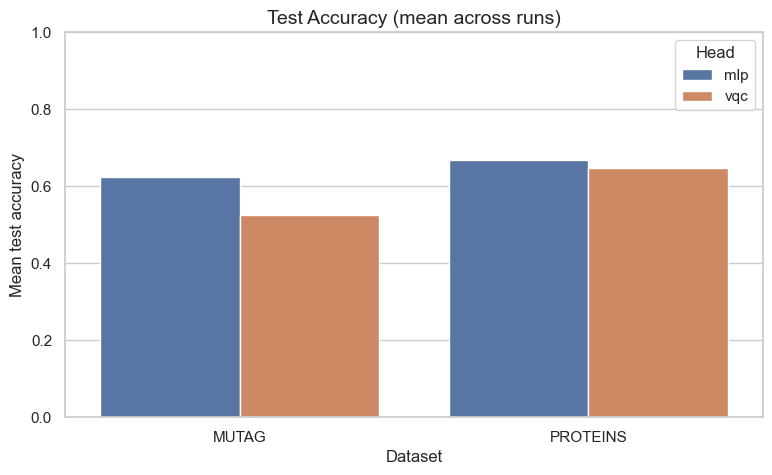

In [25]:
plt.figure()
sns.barplot(
    data=agg,
    x="dataset",
    y="test_acc_mean",
    hue="head",
    errorbar=None
)
plt.title("Test Accuracy (mean across runs)")
plt.ylabel("Mean test accuracy")
plt.xlabel("Dataset")
plt.legend(title="Head")
plt.ylim(0, 1)
plt.show()

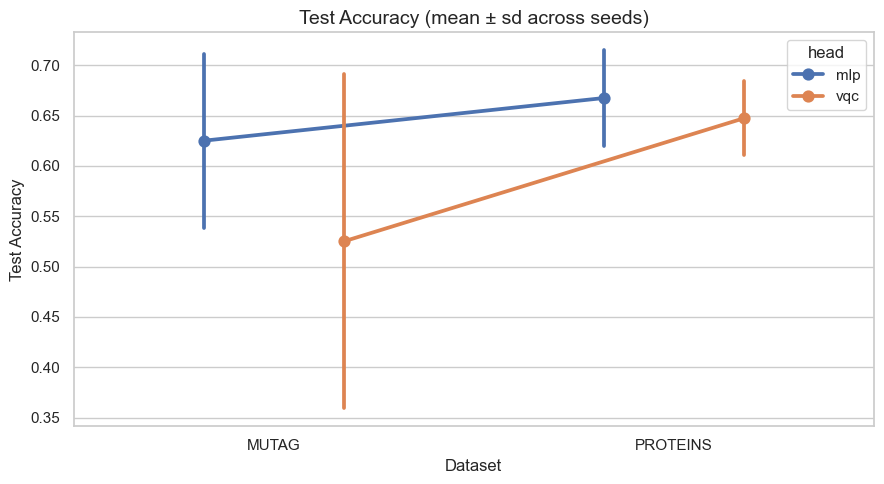

In [24]:
plt.figure()

sns.pointplot(
    data=df,
    x="dataset",
    y="test_acc",
    hue="head",
    errorbar="sd",
    dodge=0.35
)

plt.title("Test Accuracy (mean ± sd across seeds)")
plt.ylabel("Test Accuracy")
plt.xlabel("Dataset")

plt.tight_layout()

plt.savefig(FIG_DIR / "accuracy_comparison.png", dpi=300)

plt.show()

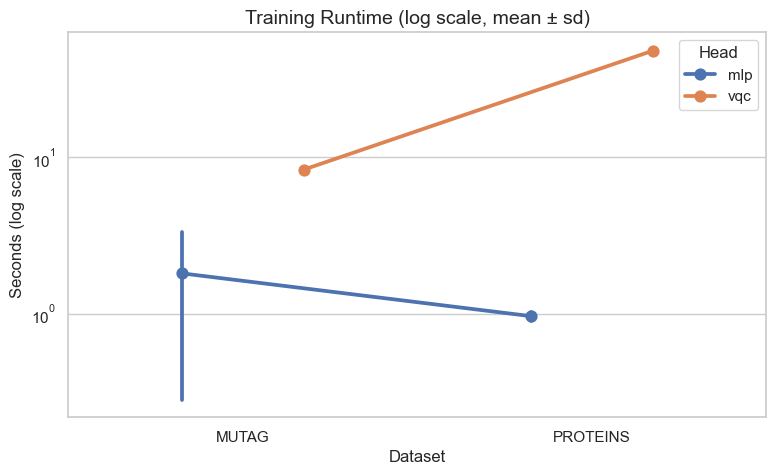

In [18]:
plt.figure()
sns.pointplot(
    data=df,
    x="dataset",
    y="seconds",
    hue="head",
    errorbar="sd",
    dodge=0.35
)
plt.yscale("log")
plt.title("Training Runtime (log scale, mean ± sd)")
plt.ylabel("Seconds (log scale)")
plt.xlabel("Dataset")
plt.legend(title="Head")
plt.show()

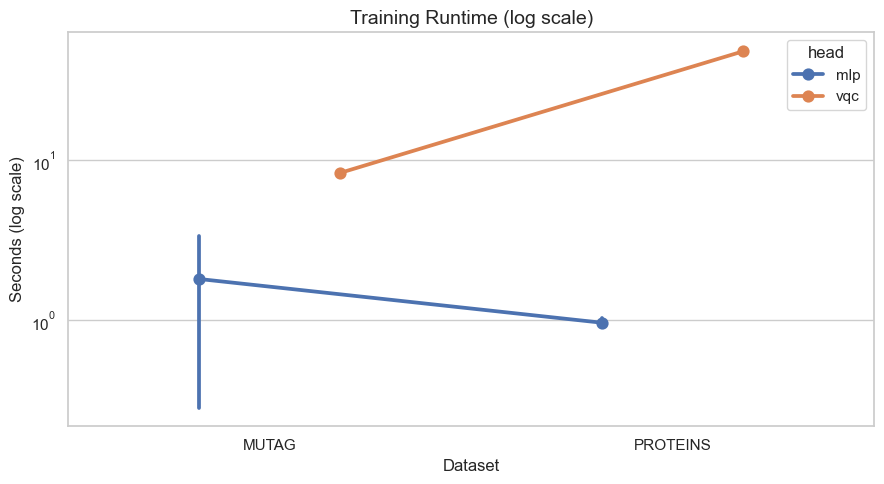

In [26]:
plt.figure()

sns.pointplot(
    data=df,
    x="dataset",
    y="seconds",
    hue="head",
    errorbar="sd",
    dodge=0.35
)

plt.yscale("log")

plt.title("Training Runtime (log scale)")
plt.ylabel("Seconds (log scale)")
plt.xlabel("Dataset")

plt.tight_layout()

plt.savefig(FIG_DIR / "runtime_comparison.png", dpi=300)

plt.show()

In [20]:
best = (
    df.sort_values("test_acc", ascending=False)
      .groupby(["dataset","head"], as_index=False)
      .head(1)
      .sort_values(["dataset","head"])
)

best[["dataset","head","seed","epochs","test_acc","val_acc","seconds","vqc_n_qubits","vqc_n_layers","vqc_shots"]]

,dataset,head,seed,epochs,test_acc,val_acc,seconds,vqc_n_qubits,vqc_n_layers,vqc_shots
12,MUTAG,mlp,123,5,0.750000,0.666667,0.518946,NaN,NaN,NaN
13,MUTAG,vqc,123,3,0.750000,0.666667,7.851665,4.0,1.0,NaN
14,PROTEINS,mlp,123,3,0.723214,0.612613,0.886587,NaN,NaN,NaN
3,PROTEINS,vqc,42,3,0.678571,0.576577,48.602869,4.0,1.0,NaN


## Final Results and Discussion

This project explored a simple hybrid quantum–classical architecture for graph classification.

A standard GCN backbone was combined with two alternative prediction heads:

- a classical **MLP head**
- a **Variational Quantum Circuit (VQC) head** implemented with PennyLane.

The experiments were conducted on two graph classification datasets from the TUDataset collection:

- **MUTAG**
- **PROTEINS**

Each configuration was evaluated using three different random seeds in order to estimate performance variability.

### Accuracy

The classical MLP head consistently achieved strong performance.

For the **MUTAG dataset**, the MLP head outperformed the VQC head on average.

For the **PROTEINS dataset**, both heads achieved comparable performance, with the VQC head reaching similar test accuracy.

Overall, the results suggest that a small variational quantum circuit can act as a competitive classifier in some settings.

### Runtime

However, a major practical limitation was observed in runtime.

The VQC head is evaluated through **classical simulation of a quantum circuit**, which introduces significant computational overhead.

Average training times:

| Model | Runtime |
|------|-------|
GCN + MLP | ~1 second |
GCN + VQC | ~48 seconds |

This difference arises from the cost of simulating quantum circuits on classical hardware.

### Key Takeaway

The experiments demonstrate that hybrid quantum–classical models can achieve competitive predictive performance on graph classification tasks.

However, when executed via classical simulation, variational quantum circuits introduce substantial computational overhead compared to classical neural network heads.

### Future Work

Potential directions for further exploration include:

- increasing the number of qubits or circuit depth
- evaluating additional graph datasets
- exploring hybrid GPU→CPU pipelines
- testing execution on real quantum hardware

This project serves as a small reproducible benchmark illustrating the practical trade-offs of hybrid quantum–classical architectures.